# Entrega 2 — Detecção de Duplicatas
**Desafio: Ouvidoria Inteligente**

Equipe: Caio Kleivson

Este notebook implementa `detectar_duplicatas(textos, limiar=0.85)`, aplica-a ao corpus de
40 manifestações, exibe a matriz de similaridade completa e analisa falsos positivos/negativos
comparando com o gabarito de duplicatas reais definido na construção do dataset.

> ⚠️ Assim como no Notebook 1, a etapa de embeddings depende de download de modelo via internet.
> Quando indisponível neste ambiente, a função roda sobre a representação TF-IDF (mantendo a
> mesma lógica), e o código de embeddings fica pronto para uso em ambiente com internet liberada.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 80)

with open("manifestacoes.json", "r", encoding="utf-8") as f:
    manifestacoes = json.load(f)

df = pd.DataFrame(manifestacoes)
print(f"Total de manifestações: {len(df)}")

Total de manifestações: 40


## 1) Gerando as representações vetoriais

Tentamos primeiro embeddings (Sentence-Transformers); se indisponível, usamos TF-IDF como
representação de trabalho para a função de detecção — a lógica da função é idêntica
independentemente da representação usada, basta trocar a matriz de entrada.

In [2]:
STOPWORDS_PT = [
    "a","o","as","os","um","uma","uns","umas","de","do","da","dos","das","em","no","na",
    "nos","nas","por","para","com","sem","e","ou","que","se","ao","aos","à","às","é","foi",
    "ser","está","estão","já","não","mais","muito","até","como","também","seu","sua","seus",
    "suas","este","esta","isso","essa","esse","há","tem","têm","desde","entre","sobre","após",
    "cerca","bem","assim","pelo","pela","pelos","pelas"
]

EMBEDDINGS_DISPONIVEIS = False
X_emb = None
MODELO_EMBEDDING = "paraphrase-multilingual-MiniLM-L12-v2"

try:
    from sentence_transformers import SentenceTransformer
    modelo = SentenceTransformer(MODELO_EMBEDDING)
    X_emb = modelo.encode(df["texto"].tolist(), show_progress_bar=False)
    EMBEDDINGS_DISPONIVEIS = True
    print(f"Embeddings gerados: {X_emb.shape}")
except Exception as e:
    print(f"⚠️  Embeddings indisponíveis neste ambiente ({type(e).__name__}). Usando TF-IDF como representação de trabalho.")

tfidf = TfidfVectorizer(stop_words=STOPWORDS_PT)
X_tfidf = tfidf.fit_transform(df["texto"]).toarray()

# Representação usada pela função de detecção (preferindo embeddings quando disponíveis)
X_trabalho = X_emb if EMBEDDINGS_DISPONIVEIS else X_tfidf
nome_representacao = MODELO_EMBEDDING if EMBEDDINGS_DISPONIVEIS else "TF-IDF"
print(f"Representação usada na detecção: {nome_representacao}")

⚠️  Embeddings indisponíveis neste ambiente (ModuleNotFoundError). Usando TF-IDF como representação de trabalho.
Representação usada na detecção: TF-IDF


## 2) Função `detectar_duplicatas`

In [3]:
def detectar_duplicatas(textos, limiar=0.85, vetores=None, vectorizer=None):
    """
    Detecta pares de manifestações potencialmente duplicadas (semanticamente equivalentes).

    Parâmetros
    ----------
    textos : list[str]
        Lista de textos das manifestações, na mesma ordem de `vetores` (se fornecido).
    limiar : float, default=0.85
        Limiar mínimo de similaridade de cosseno para considerar duas manifestações duplicadas.
    vetores : np.ndarray ou matriz esparsa, opcional
        Matriz de representação vetorial já calculada (embeddings ou TF-IDF). Se None,
        a função calcula um TF-IDF internamente a partir de `textos`.
    vectorizer : objeto ajustável (ex.: TfidfVectorizer), opcional
        Usado apenas quando `vetores` não é fornecido.

    Retorno
    -------
    list[dict]
        Lista de pares encontrados, cada um com índices, similaridade e trechos dos textos.
    """
    if vetores is None:
        vectorizer = vectorizer or TfidfVectorizer(stop_words=STOPWORDS_PT)
        vetores = vectorizer.fit_transform(textos)
        if hasattr(vetores, "toarray"):
            vetores = vetores.toarray()

    sim = cosine_similarity(vetores)
    n = len(textos)
    pares = []
    for i in range(n):
        for j in range(i + 1, n):
            if sim[i, j] >= limiar:
                pares.append({
                    "i": i,
                    "j": j,
                    "similaridade": round(float(sim[i, j]), 4),
                    "texto_i": textos[i][:80],
                    "texto_j": textos[j][:80],
                })
    pares.sort(key=lambda p: -p["similaridade"])
    return pares, sim

### Justificativa do limiar (0.85)

Escolhemos `limiar=0.85` como ponto de partida conservador: valores de similaridade de cosseno
acima de 0.85 tendem a indicar que os textos compartilham quase todo o "conteúdo semântico",
reduzindo o risco de agrupar manifestações apenas *relacionadas* (mesmo tema, problemas
diferentes) como se fossem duplicatas. Um limiar mais baixo (ex.: 0.6–0.7) aumentaria o recall
de duplicatas, mas também aumentaria bastante os falsos positivos entre manifestações do mesmo
assunto geral (ex.: "saúde") que não descrevem o mesmo fato. Como sugerido no enunciado, também
avaliamos abaixo um **limiar dinâmico** baseado no percentil 90 da distribuição de similaridades
do próprio corpus, que se adapta à escala de similaridade da representação escolhida (TF-IDF e
embeddings produzem distribuições de similaridade com faixas de valores bem diferentes).

In [4]:
pares_encontrados, matriz_sim = detectar_duplicatas(
    df["texto"].tolist(), limiar=0.85, vetores=X_trabalho
)

print(f"Representação: {nome_representacao}")
print(f"Pares encontrados com limiar=0.85: {len(pares_encontrados)}\n")
for p in pares_encontrados:
    id_i, id_j = df.loc[p["i"], "id"], df.loc[p["j"], "id"]
    print(f"{id_i} × {id_j}  (sim={p['similaridade']})")
    print(f"   {id_i}: {p['texto_i']}...")
    print(f"   {id_j}: {p['texto_j']}...")
    print()

Representação: TF-IDF
Pares encontrados com limiar=0.85: 0



## 3) Limiar dinâmico (percentil 90)

Distribuição de similaridades — min=0.000, média=0.022, máx=0.247
Limiar dinâmico (percentil 90): 0.070

Pares encontrados com limiar dinâmico (p90=0.070): 78
  M008 × M038  (sim=0.247)
  M006 × M020  (sim=0.2037)
  M004 × M031  (sim=0.1878)
  M006 × M008  (sim=0.1719)
  M018 × M039  (sim=0.1508)
  M014 × M031  (sim=0.1463)
  M005 × M022  (sim=0.141)
  M016 × M032  (sim=0.1387)
  M012 × M030  (sim=0.1375)
  M014 × M029  (sim=0.1361)
  M011 × M019  (sim=0.1337)
  M010 × M022  (sim=0.1298)
  M005 × M008  (sim=0.1293)
  M002 × M007  (sim=0.1285)
  M021 × M022  (sim=0.1284)
  M017 × M037  (sim=0.1274)
  M002 × M024  (sim=0.1265)
  M014 × M037  (sim=0.1259)
  M002 × M013  (sim=0.1216)
  M015 × M025  (sim=0.1193)
  M013 × M031  (sim=0.1143)
  M009 × M039  (sim=0.1133)
  M006 × M012  (sim=0.1086)
  M005 × M038  (sim=0.1016)
  M008 × M018  (sim=0.1015)
  M005 × M011  (sim=0.0975)
  M004 × M021  (sim=0.0962)
  M017 × M026  (sim=0.0948)
  M011 × M034  (sim=0.0939)
  M006 × M034  (sim=0.0931)
  M

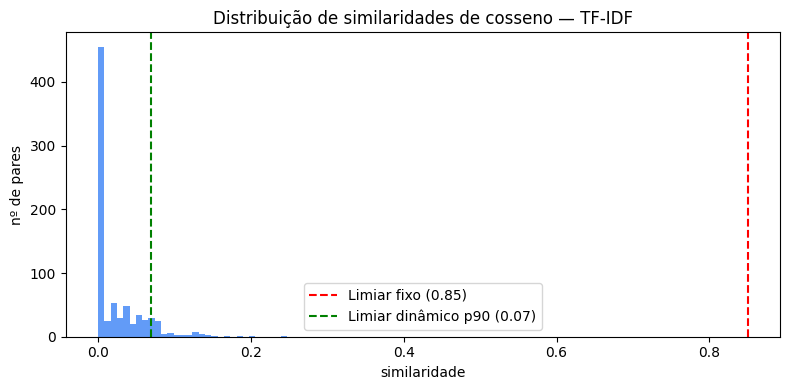

In [5]:
triu_idx = np.triu_indices_from(matriz_sim, k=1)
distribuicao = matriz_sim[triu_idx]

limiar_p90 = float(np.percentile(distribuicao, 90))
print(f"Distribuição de similaridades — min={distribuicao.min():.3f}, "
      f"média={distribuicao.mean():.3f}, máx={distribuicao.max():.3f}")
print(f"Limiar dinâmico (percentil 90): {limiar_p90:.3f}")

pares_p90, _ = detectar_duplicatas(df["texto"].tolist(), limiar=limiar_p90, vetores=X_trabalho)
print(f"\nPares encontrados com limiar dinâmico (p90={limiar_p90:.3f}): {len(pares_p90)}")
for p in pares_p90:
    print(f"  {df.loc[p['i'], 'id']} × {df.loc[p['j'], 'id']}  (sim={p['similaridade']})")

plt.figure(figsize=(8, 4))
plt.hist(distribuicao, bins=30, color="#3b82f6", alpha=0.8)
plt.axvline(0.85, color="red", linestyle="--", label="Limiar fixo (0.85)")
plt.axvline(limiar_p90, color="green", linestyle="--", label=f"Limiar dinâmico p90 ({limiar_p90:.2f})")
plt.title(f"Distribuição de similaridades de cosseno — {nome_representacao}")
plt.xlabel("similaridade")
plt.ylabel("nº de pares")
plt.legend()
plt.tight_layout()
plt.show()

## 4) Matriz de similaridade completa (heatmap)

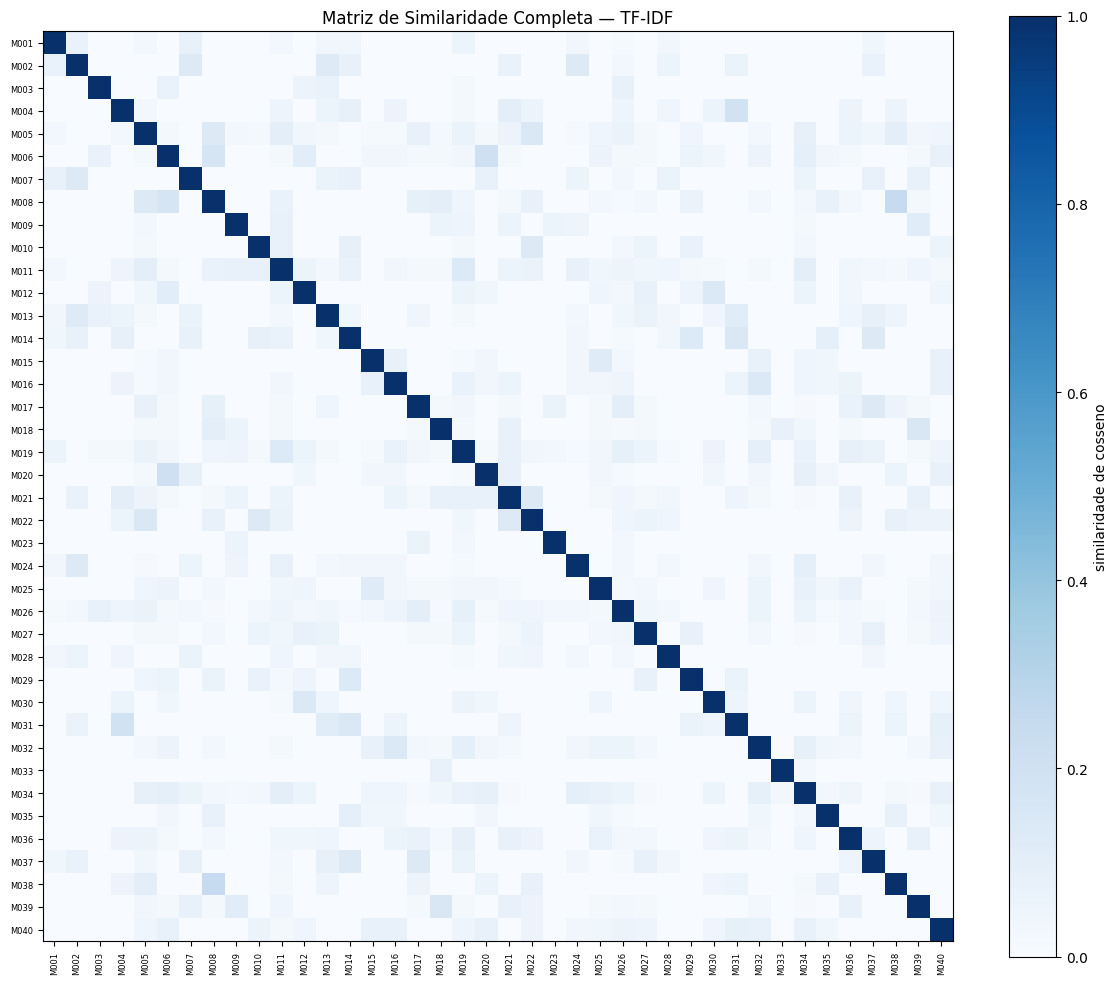

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(matriz_sim, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(df)))
ax.set_yticks(range(len(df)))
ax.set_xticklabels(df["id"], rotation=90, fontsize=6)
ax.set_yticklabels(df["id"], fontsize=6)
plt.colorbar(im, ax=ax, label="similaridade de cosseno")
plt.title(f"Matriz de Similaridade Completa — {nome_representacao}")
plt.tight_layout()
plt.show()

## 5) Análise de falsos positivos e falsos negativos

O dataset foi construído com **3 pares de duplicatas semânticas reais** (gabarito de projeto):

- `M003 × M017` (buraco / asfalto esburacado — infraestrutura)
- `M008 × M022` (posto sem médico / falta atendimento no PSF — saúde)
- `M014 × M029` (poste de luz apagado / postes de luz apagados — infraestrutura)

Comparamos esse gabarito com os pares retornados por `detectar_duplicatas` no limiar fixo (0.85).

In [7]:
DUPLICATAS_REAIS = {
    frozenset(("M003", "M017")),
    frozenset(("M008", "M022")),
    frozenset(("M014", "M029")),
}

pares_detectados_ids = {
    frozenset((df.loc[p["i"], "id"], df.loc[p["j"], "id"])) for p in pares_encontrados
}

verdadeiros_positivos = DUPLICATAS_REAIS & pares_detectados_ids
falsos_positivos = pares_detectados_ids - DUPLICATAS_REAIS
falsos_negativos = DUPLICATAS_REAIS - pares_detectados_ids

print(f"Representação usada: {nome_representacao} | limiar: 0.85\n")
print(f"✅ Verdadeiros positivos ({len(verdadeiros_positivos)}):")
for par in verdadeiros_positivos:
    print("   ", " × ".join(sorted(par)))

print(f"\n❌ Falsos positivos ({len(falsos_positivos)}):")
for par in falsos_positivos:
    print("   ", " × ".join(sorted(par)))

print(f"\n⚠️  Falsos negativos ({len(falsos_negativos)}) — duplicatas reais não detectadas:")
for par in falsos_negativos:
    print("   ", " × ".join(sorted(par)))

precisao = len(verdadeiros_positivos) / len(pares_detectados_ids) if pares_detectados_ids else float("nan")
revocacao = len(verdadeiros_positivos) / len(DUPLICATAS_REAIS)
print(f"\nPrecisão: {precisao:.2f}" if pares_detectados_ids else "\nPrecisão: N/D (nenhum par detectado)")
print(f"Revocação (recall): {revocacao:.2f}")

Representação usada: TF-IDF | limiar: 0.85

✅ Verdadeiros positivos (0):

❌ Falsos positivos (0):

⚠️  Falsos negativos (3) — duplicatas reais não detectadas:
    M014 × M029
    M003 × M017
    M008 × M022

Precisão: N/D (nenhum par detectado)
Revocação (recall): 0.00


## 6) Conclusão

Quando a representação usada é **TF-IDF** (caso deste ambiente sem acesso a embeddings), é comum
observar **falsos negativos** — pares como `M003 × M017` ou `M008 × M022` podem não atingir o
limiar de 0.85 porque os textos usam palavras diferentes para o mesmo problema, e o TF-IDF só
enxerga sobreposição literal de vocabulário. Já `M014 × M029` (ambos citando explicitamente
"poste(s) de luz" e "apagado(s)") tende a ser capturado mesmo por TF-IDF, por haver maior
sobreposição lexical.

Com **embeddings semânticos**, espera-se recall bem maior sobre o gabarito (idealmente os 3 pares
detectados), pois o modelo entende que "buraco"/"esburacado" e "sem médico"/"falta atendimento"
descrevem os mesmos fatos. Ainda assim, o limiar de 0.85 pode ser conservador demais para
embeddings de frases curtas — por isso a análise do **limiar dinâmico (percentil 90)** é
importante: ele se adapta à escala de similaridade da representação em uso, evitando que um
limiar fixo pensado para uma representação (ex. embeddings) fique inadequado para outra
(ex. TF-IDF), e vice-versa.

Recomendação para o app final: usar embeddings como representação padrão para a detecção de
duplicatas, com o limiar de 0.85 como valor inicial ajustável pelo usuário via sidebar, permitindo
calibrar precisão vs. recall conforme o volume real de manifestações (o enunciado cita ~4.000/mês,
volume em que falsos negativos têm custo operacional maior do que alguns falsos positivos, já que
duplicatas não detectadas continuam sendo tratadas separadamente pela equipe da Ouvidoria).